# ResNet testing figures

In [1]:
import csv
import json
import re
import sys
import time
import os
import numpy as np
import torch
from pathlib import Path
from argparse import ArgumentParser


In [2]:

results_dict = {
    "methods":[
        {
            "name": "Conditional",
            "evaluation_id": "synth_to_real_ratio_comparison_conditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "Unconditional",
            "evaluation_id": "synth_to_real_ratio_comparison_V1_unconditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "SDEdit Conditional",
            "evaluation_id": "synth_to_real_ratio_comparison_V1_SDEdit_0.9_conditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "SDEdit Unconditional",
            "evaluation_id": "synth_to_real_ratio_comparison_V1_SDEdit_0.9_unconditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "XPaste",
            "evaluation_id": "synth_to_real_ratio_comparison_V1_xpaste",
            "x": [],
            "y": [],
            "y_std": []
        },

    ]
}
# config_path = "/home/ap/cloud/Master/aris_master/testing/02-19_normal-wood_impregnated-wood_1024_splits_final/config.json"

test_folder_path = "/home/ap/cloud/master/aris_master/Testing"

In [3]:

results_dict = {
    "methods":[
        {
            "name": "Conditional",
            "evaluation_id": "synth_to_real_ratio_comparison_conditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "Unconditional",
            "evaluation_id": "synth_to_real_ratio_comparison_unconditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "SDEdit Conditional",
            "evaluation_id": "synth_to_real_ratio_comparison_V1_SDEdit_0.9_conditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "SDEdit Unconditional",
            "evaluation_id": "synth_to_real_ratio_comparison_V1_SDEdit_0.9_unconditional",
            "x": [],
            "y": [],
            "y_std": []
        },
        {
            "name": "XPaste",
            "evaluation_id": "synth_to_real_ratio_comparison_V1_xpaste",
            "x": [],
            "y": [],
            "y_std": []
        },

    ]
}
# config_path = "/home/ap/cloud/Master/aris_master/testing/02-19_normal-wood_impregnated-wood_1024_splits_final/config.json"

test_folder_path = "/home/ap/cloud/master/aris_master/Testing"

In [4]:
def fetch_results_by_evaluation_id(evaluation_id, base_folder=test_folder_path, json_filename = "results.json", force=False, verbose=False):
    """
    Find all 'results.json' files under base_folder and ensure each file contains
    a 'unique_evaluation_id' equal to the provided evaluation_id.

    Returns:
        list[Path]: Paths to matching results.json files.

    Raises:
        FileNotFoundError: If no results.json files are found.
        ValueError: If a file is missing 'unique_evaluation_id' or has a mismatched value.
        json.JSONDecodeError: If a results.json file is invalid JSON.
    """
    base_path = Path(base_folder)
    results_files = list(base_path.rglob(json_filename))

    if not results_files:
        raise FileNotFoundError(f"No '{json_filename}' files found in: {base_path}")

    matching_files = []

    for file_path in results_files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        if "evaluation_id" not in data and not force:
            if verbose:
                print(f"Skipping {file_path} due to missing 'evaluation_id'")
            continue
        
        if not force:
            if data["evaluation_id"] != evaluation_id:
                if verbose:
                    print(f"Skipping {file_path} due to mismatched evaluation_id: {data['evaluation_id']}")
                continue
    

        matching_files.append(file_path)

    return matching_files


In [11]:
# if fetch_type == "results":
#     # Fetch config files matching the evaluation_id
#     print(results_dict)
#     for method, aug_dict in results_dict.items():
#         for aug_type, result_info in aug_dict.items():
#             result_file_path = Path(result_info["path"])
#             # Check if file exists            
#             if not result_file_path.is_file():
#                 print(f"File not found: {result_file_path}")
#                 continue
#             with result_file_path.open("r", encoding="utf-8") as f:
#                 data = json.load(f)
            
#             x = []
#             y = []
#             y_std = []
#             for entry in data["splits"]:
#                 val_acc = []
#                 f1_score = []
#                 for run in entry["runs"]:
#                     val_acc.append(run["val_accuracy"])
#                     #f1_score.append(run["f1_score"])
#                 # Calculate mean and std for val_acc and f1_score
#                 x.append(entry["synthetic_image_count"])
#                 y.append(np.mean(val_acc))
#                 y_std.append(np.std(val_acc))
#                 # f1_score_mean = np.mean(f1_score)
#                 # f1_score_std = np.std(f1_score)
#                 # Sort y values based on x (synthetic_image_count)
#                 # Ensure iterables before zipping/sorting (x, y, y_std are scalars per split)


#             xy_sorted = sorted(zip(x, y), key=lambda t: t[0])
#             x_sorted, y_sorted = map(list, zip(*xy_sorted))
#             print(f"{method} - {aug_type}")
#             print(f"x: {x_sorted}")
#             print(f"y: {y_sorted}")

#             # If using mean/std:
#             xyz_sorted = sorted(zip(x, y, y_std), key=lambda t: t[0])
#             x_sorted, y_sorted, y_std_sorted = map(list, zip(*xyz_sorted))
#             y_sorted = [float(100*y) for y in y_sorted]
#             y_std_sorted = [float(100*y) for y in y_std_sorted]

#             results_dict[method][aug_type]["x"] = x_sorted
#             results_dict[method][aug_type]["y"] = y_sorted
#             results_dict[method][aug_type]["y_std"] = y_std_sorted
# elif fetch_type == "evaluation_id":
    # Fetch results files matching the evaluation_id
for method in results_dict["methods"]:
    results_path_matches = fetch_results_by_evaluation_id(method["evaluation_id"], test_folder_path)
    if not results_path_matches:
        print(f"No results found for evaluation_id: {method['evaluation_id']}")
        continue
    if len(results_path_matches) > 1:
        print(f"Warning: Multiple results files found for evaluation_id: {method['evaluation_id']}. Using the first one found.")
    results_path = results_path_matches[0]  # Use only the first file if multiple are found
    print(f"Processing results from: {results_path}")
    y_mean = []
    y_std = []
    x = []
    with results_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    for entry in data["splits"]:
        val_acc = []
        test_acc = []
        f1_score = []
        if entry["real_image_count"] == 0:
            print(f"Skipping real data point (real_image_count=0) for synthetic_image_count={entry['synthetic_image_count']}")
            continue  # Skip the real data point for plotting purposes
        for run in entry["runs"]:
            val_acc.append(run["val_accuracy"])
            test_acc.append(run.get("test_accuracy", None))  # Use get to avoid KeyError if test_accuracy is missing
            
            #f1_score.append(run["f1_score"])
        # Calculate mean and std for val_acc and f1_score
        val_acc_mean = np.mean(val_acc)
        val_acc_std = np.std(val_acc)
        f1_score_mean = np.mean(f1_score)

        f1_score_std = np.std(f1_score)
        y_mean.append(float(val_acc_mean))

        y_std.append(float(val_acc_std))
        x.append(entry["synthetic_image_count"])
    
    # xy_sorted = sorted(zip(x, y_mean), key=lambda t: t[0])
    # x_sorted, y_sorted = map(list, zip(*xy_sorted))
    # print(f"x: {x_sorted}")
    # print(f"y: {y_sorted}")

    # If using mean/std:
    x.append(0)  # Add the real data point with 0 synthetic images
    y_mean.append(0.9232)  # Real data point mean accuracy
    y_std.append(0.0059)  # Real data point std deviation
    xyz_sorted = sorted(zip(x, y_mean, y_std), key=lambda t: t[0])
    x_sorted, y_sorted, y_std_sorted = map(list, zip(*xyz_sorted))
    y_sorted = [float(100*y) for y in y_sorted]
    y_std_sorted = [float(100*y) for y in y_std_sorted]

    method["x"] = x_sorted
    method["y"] = y_sorted
    method["y_std"] = y_std_sorted
    print(x_sorted)
    print(y_sorted)

print(results_dict)

Processing results from: /home/ap/cloud/master/aris_master/Testing/1000_real/conditional_diffusion/results.json
[0, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000, 12000, 16000, 20000, 24000, 28000, 32000, 36000, 40000]
[92.32000000000001, 92.53823999999999, 92.58082, 91.8064, 93.03774, 92.25558, 92.39112, 91.72506, 92.21295999999998, 91.3998, 90.85768, 91.35722, 91.41916, 91.42304000000001, 90.88480000000001, 91.4424, 90.68732]
Processing results from: /home/ap/cloud/master/aris_master/Testing/1000_real/unconditional_diffusion/results.json
[0, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000, 12000, 16000, 20000, 24000, 28000, 32000, 36000, 40000]
[92.32000000000001, 93.1036, 93.20814, 92.73572, 92.79382000000001, 92.84027999999999, 92.45689999999999, 92.697, 92.70476000000001, 92.07744, 92.39108, 92.61956, nan, nan, nan, nan, nan]
Processing results from: /home/ap/cloud/master/aris_master/Testing/1000_real/___SDEdit_0.9_conditional/results.json
[0, 1000, 2000, 3000, 4000, 5000, 6000,

/home/ap/cloud/master/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ap/cloud/master/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/ap/cloud/master/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ap/cloud/master/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/ap/cloud/master/aris_master/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [12]:
# def bar_chart_with_error_bars(x, y_mean, y_std):
#     import matplotlib.pyplot as plt
#     import numpy as np

#     x_pos = np.arange(len(x))

#     bars = plt.bar(
#         x_pos, y_mean, yerr=y_std, align='center',
#         alpha=0.7, ecolor='black', capsize=10
#     )
#     plt.xticks(x_pos, x)
#     plt.xlabel('Resolution')
#     plt.ylabel('Mean Accuracy')
#     plt.title('Mean Accuracy by Resolution')
#     plt.grid(axis='y')

#     # Add accuracy value on top of each bar
#     y_max = max(m + s for m, s in zip(y_mean, y_std))
#     plt.ylim(0, y_max + 0.05)
#     for i, bar in enumerate(bars):
#         height = bar.get_height()
#         plt.text(
#             bar.get_x() + bar.get_width() / 2 + 0.27,
#             height  + 0,
#             f"{height:.3f}",
#             ha='center',
#             va='bottom',
#             fontsize=9
#         )

#     plt.tight_layout()
#     plt.show()

# bar_chart_with_error_bars(x_sorted, y_mean_sorted, y_std_sorted)

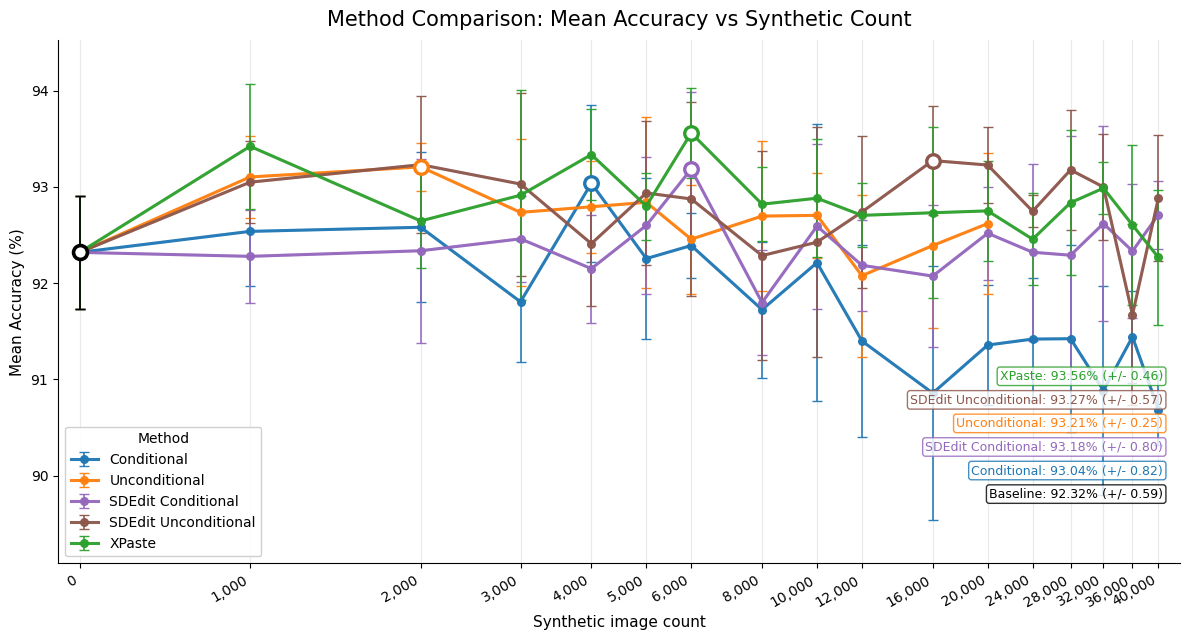

Peak accuracy by method (excluding x=0):
- XPaste: 93.561% (+/- 0.463) at x=6,000
- SDEdit Unconditional: 93.274% (+/- 0.569) at x=16,000
- Unconditional: 93.208% (+/- 0.250) at x=2,000
- SDEdit Conditional: 93.185% (+/- 0.803) at x=6,000
- Conditional: 93.038% (+/- 0.816) at x=4,000
Baseline (x=0): 92.320% (+/- 0.590)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Toggle this:
# False -> linear x (synthetic image count)
# True  -> log-like x using log10(1 + synthetic_count)
use_logarithmic_x = True

# Optional visual override for x=0 point placement.
# Moves the baseline to a small synthetic-count position while keeping label "0".
override_zero_position = True
zero_position_synth_count = 500

methods = results_dict.get("methods", []) if isinstance(results_dict, dict) else []

fig, ax = plt.subplots(figsize=(12, 6.5))
all_x = set()
plotted_any = False
peak_points = []
baseline_candidates = []

# Fixed palette for visual consistency across reruns
palette = {
    "Conditional": "#1f77b4",
    "Unconditional": "#ff7f0e",
    "SDEdit Conditional": "#9467bd",
    "SDEdit Unconditional": "#8c564b",
    "XPaste": "#2ca02c",
}


def x_transform(v):
    if not use_logarithmic_x:
        return v
    # log1p-style transform keeps x=0 defined while spreading high counts.
    return np.log10(1.0 + v)


zero_x_override = float(zero_position_synth_count)

for method in methods:
    name = method.get("name", "Unnamed")
    x_vals = method.get("x", []) or []
    y_vals = method.get("y", []) or []
    y_std = method.get("y_std", []) or []

    if not x_vals or not y_vals or len(x_vals) != len(y_vals):
        print(f"Skipping {name}: missing or mismatched x/y data")
        continue

    # Sort each series by x to avoid visual zig-zag if input ordering changes
    xy = sorted(zip(x_vals, y_vals), key=lambda p: p[0])
    x_vals = [p[0] for p in xy]
    y_vals = [p[1] for p in xy]

    if y_std and len(y_std) == len(y_vals):
        xys = sorted(zip(method.get("x", []), method.get("y", []), y_std), key=lambda p: p[0])
        y_std = [p[2] for p in xys]
    else:
        y_std = []

    x_plot = [x_transform(zero_x_override if (override_zero_position and x == 0) else x) for x in x_vals]

    all_x.update(x_vals)
    color = palette.get(name, None)

    # Capture baseline candidate from the 0-synthetic data point
    if 0 in x_vals:
        zero_idx = x_vals.index(0)
        baseline_candidates.append(
            {
                "name": name,
                "x": 0,
                "x_plot": x_plot[zero_idx],
                "y": y_vals[zero_idx],
                "y_std": y_std[zero_idx] if y_std else None,
            }
        )

    # Rule: method peaks must exclude x=0 synthetic images
    nonzero_idx = [i for i, x in enumerate(x_vals) if x != 0]
    if not nonzero_idx:
        print(f"Skipping peak label for {name}: no non-zero synthetic data points")
    else:
        peak_i = max(nonzero_idx, key=lambda i: y_vals[i])
        peak_points.append(
            {
                "name": name,
                "x": x_vals[peak_i],
                "x_plot": x_plot[peak_i],
                "y": y_vals[peak_i],
                "y_std": y_std[peak_i] if y_std else None,
                "color": color,
            }
        )

    # Light interpolated guide line to make trends easier to read
    if len(x_plot) >= 3 and len(set(x_plot)) >= 3:
        x_dense = np.linspace(min(x_plot), max(x_plot), 250)
        y_dense = np.interp(x_dense, x_plot, y_vals)
        ax.plot(x_dense, y_dense, linewidth=2.0, alpha=0.20, color=color, zorder=1)

    if y_std:
        ax.errorbar(
            x_plot,
            y_vals,
            yerr=y_std,
            fmt="o-",
            linewidth=2.2,
            markersize=5.5,
            capsize=3.5,
            elinewidth=1.2,
            alpha=0.95,
            color=color,
            label=name,
            zorder=3,
        )
    else:
        ax.plot(
            x_plot,
            y_vals,
            "o-",
            linewidth=2.2,
            markersize=5.5,
            alpha=0.95,
            color=color,
            label=name,
            zorder=3,
        )

    plotted_any = True

if plotted_any:
    x_ticks = sorted(all_x)

    x_tick_positions = []
    x_tick_labels = []
    for x in x_ticks:
        if x == 0 and override_zero_position:
            x_tick_positions.append(x_transform(zero_x_override))
            x_tick_labels.append("0")
        else:
            x_tick_positions.append(x_transform(x))
            x_tick_labels.append(f"{int(x):,}")

    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_labels, rotation=30, ha="right")

    ax.set_xlabel("Synthetic image count", fontsize=11)
    ax.set_ylabel("Mean Accuracy (%)", fontsize=11)
    mode_name = "" if use_logarithmic_x else ""
    ax.set_title(f"Method Comparison: Mean Accuracy vs Synthetic Count", fontsize=15, pad=10)

    # Keep only x-grid lines (one per tick/data point)
    ax.grid(True, axis="x", alpha=0.28, linewidth=0.8)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)

    # Subtle frame cleanup
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Sort in descending order by mean accuracy
    ranked_peaks = sorted(peak_points, key=lambda p: p["y"], reverse=True)

    # Baseline (x=0) used for black performance box and marker
    baseline = baseline_candidates[0] if baseline_candidates else None

    # Highlight each peak point with white center and thick colored border (smaller markers)
    for peak in ranked_peaks:
        ax.scatter(
            peak["x_plot"],
            peak["y"],
            s=95,
            facecolors="white",
            edgecolors=peak["color"],
            linewidths=2.4,
            zorder=7,
        )

    # Highlight baseline data point (x=0) in black with white center (smaller marker)
    if baseline is not None:
        ax.scatter(
            baseline["x_plot"],
            baseline["y"],
            s=100,
            facecolors="white",
            edgecolors="black",
            linewidths=2.6,
            zorder=8,
        )

        # Force baseline error bars to black at x=0
        if baseline["y_std"] is not None:
            ax.errorbar(
                baseline["x_plot"],
                baseline["y"],
                yerr=baseline["y_std"],
                fmt="none",
                ecolor="black",
                elinewidth=1.2,
                capsize=3.5,
                zorder=7,
            )

    # Build one combined descending list for all boxes, including baseline
    ranking_boxes = []
    for peak in ranked_peaks:
        ranking_boxes.append(
            {
                "name": peak["name"],
                "y": peak["y"],
                "y_std": peak["y_std"],
                "color": peak["color"],
            }
        )
    if baseline is not None:
        ranking_boxes.append(
            {
                "name": "Baseline",
                "y": baseline["y"],
                "y_std": baseline["y_std"],
                "color": "black",
            }
        )

    ranking_boxes = sorted(ranking_boxes, key=lambda p: p["y"], reverse=True)

    # Draw stacked performance boxes at bottom-right with slightly larger spacing
    x_box = 0.985
    y_start = 0.12
    y_step = 0.045
    for i, item in enumerate(ranking_boxes):
        y_box = y_start + (len(ranking_boxes) - 1 - i) * y_step
        if item["y_std"] is not None:
            txt = f"{item['name']}: {item['y']:.2f}% (+/- {item['y_std']:.2f})"
        else:
            txt = f"{item['name']}: {item['y']:.2f}%"

        ax.text(
            x_box,
            y_box,
            txt,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color=item["color"],
            bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=item["color"], alpha=0.82),
            zorder=6,
        )

    ax.legend(title="Method", frameon=True, framealpha=0.92)
    ax.margins(x=0.02, y=0.10)

    plt.tight_layout()
    plt.show()

    # Print peak summary sorted by peak accuracy (descending)
    print("Peak accuracy by method (excluding x=0):")
    for peak in ranked_peaks:
        if peak["y_std"] is not None:
            print(f"- {peak['name']}: {peak['y']:.3f}% (+/- {peak['y_std']:.3f}) at x={peak['x']:,}")
        else:
            print(f"- {peak['name']}: {peak['y']:.3f}% at x={peak['x']:,}")

    if baseline is not None:
        if baseline["y_std"] is not None:
            print(f"Baseline (x=0): {baseline['y']:.3f}% (+/- {baseline['y_std']:.3f})")
        else:
            print(f"Baseline (x=0): {baseline['y']:.3f}%")
else:
    print("No plottable method data found in results_dict['methods'].")

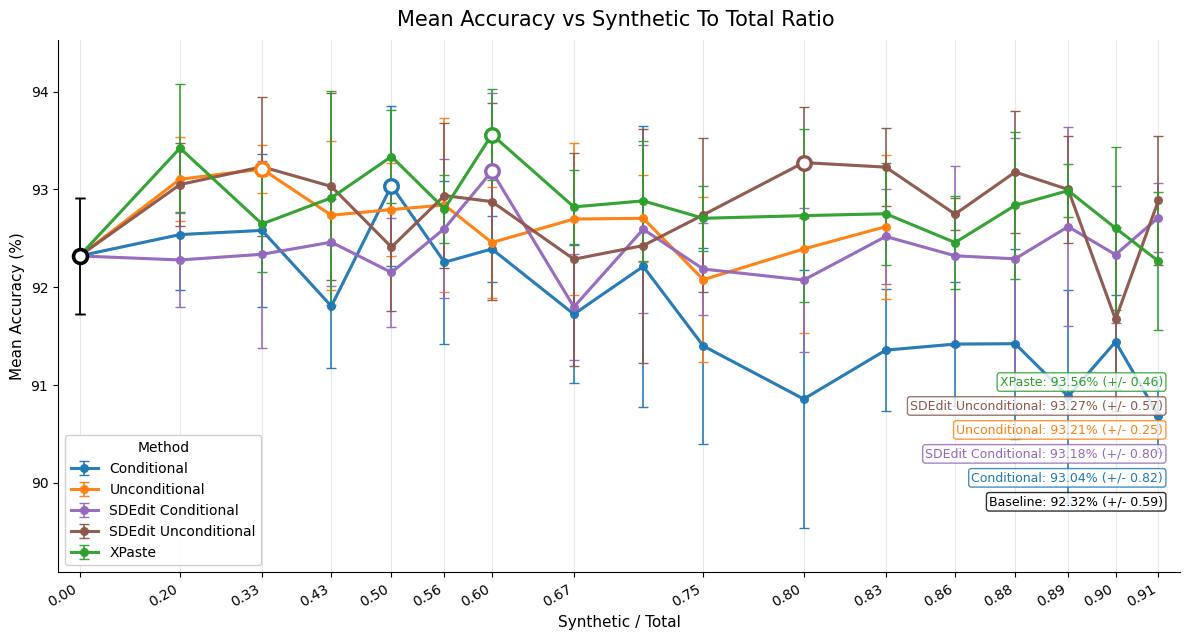

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Toggle this:
# False -> linear ratio axis
# True  -> logarithmic-like stretch toward 1.0 (points near 1 spread out)
use_logarithmic_ratio_x = True

methods = results_dict.get("methods", []) if isinstance(results_dict, dict) else []

fig, ax = plt.subplots(figsize=(12, 6.5))
plotted_any = False
peak_points = []
baseline_candidates = []

palette = {
    "Conditional": "#1f77b4",
    "Unconditional": "#ff7f0e",
    "SDEdit Conditional": "#9467bd",
    "SDEdit Unconditional": "#8c564b",
    "XPaste": "#2ca02c",
}


def synth_ratio(synth_count, real_count=4000):
    return synth_count / (synth_count + real_count)


def x_transform(r):
    if not use_logarithmic_ratio_x:
        return r
    # Stretch values as they approach 1 while keeping low ratios comparatively compressed.
    eps = 1e-6
    return -np.log10(np.clip(1.0 - r, eps, None))


for method in methods:
    name = method.get("name", "Unnamed")
    x_vals = method.get("x", []) or []
    y_vals = method.get("y", []) or []
    y_std = method.get("y_std", []) or []

    if not x_vals or not y_vals or len(x_vals) != len(y_vals):
        print(f"Skipping {name}: missing or mismatched x/y data")
        continue

    xyz = list(zip(x_vals, y_vals, y_std if len(y_std) == len(y_vals) else [None] * len(y_vals)))
    xyz = sorted(xyz, key=lambda p: p[0])

    x_counts = [p[0] for p in xyz]
    y_sorted = [p[1] for p in xyz]
    yerr_sorted = [p[2] for p in xyz]

    x_ratio = [synth_ratio(xc) for xc in x_counts]
    x_plot = [x_transform(r) for r in x_ratio]

    color = palette.get(name, None)

    # Baseline candidate from x=0
    if 0 in x_counts:
        i0 = x_counts.index(0)
        baseline_candidates.append(
            {
                "name": name,
                "x_ratio": x_ratio[i0],
                "x_plot": x_plot[i0],
                "y": y_sorted[i0],
                "y_std": yerr_sorted[i0],
            }
        )

    # Peak must exclude x=0
    nonzero_idx = [i for i, x in enumerate(x_counts) if x != 0]
    if nonzero_idx:
        best_i = max(nonzero_idx, key=lambda i: y_sorted[i])
        peak_points.append(
            {
                "name": name,
                "x_plot": x_plot[best_i],
                "y": y_sorted[best_i],
                "y_std": yerr_sorted[best_i],
                "color": color,
            }
        )

    # Light trend guide
    if len(x_plot) >= 3 and len(set(x_plot)) >= 3:
        xd = np.linspace(min(x_plot), max(x_plot), 250)
        yd = np.interp(xd, x_plot, y_sorted)
        ax.plot(xd, yd, linewidth=2.0, alpha=0.20, color=color, zorder=1)

    # Main line + error bars
    if all(e is not None for e in yerr_sorted):
        ax.errorbar(
            x_plot,
            y_sorted,
            yerr=yerr_sorted,
            fmt="o-",
            linewidth=2.2,
            markersize=5.5,
            capsize=3.5,
            elinewidth=1.2,
            alpha=0.95,
            color=color,
            label=name,
            zorder=3,
        )
    else:
        ax.plot(
            x_plot,
            y_sorted,
            "o-",
            linewidth=2.2,
            markersize=5.5,
            alpha=0.95,
            color=color,
            label=name,
            zorder=3,
        )

    plotted_any = True

if plotted_any:
    # Build ticks from meaningful synthetic counts
    tick_counts = sorted({0, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 12000, 16000, 20000, 24000, 28000, 32000, 36000, 40000})
    tick_ratios = [synth_ratio(c) for c in tick_counts]
    tick_positions = [x_transform(r) for r in tick_ratios]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{r:.2f}" for r in tick_ratios], rotation=30, ha="right")

    ax.set_xlabel("Synthetic / Total", fontsize=11)
    ax.set_ylabel("Mean Accuracy (%)", fontsize=11)
    title_mode = "" if use_logarithmic_ratio_x else ""
    ax.set_title(f"Mean Accuracy vs Synthetic To Total Ratio {title_mode}", fontsize=15, pad=10)

    ax.grid(True, axis="x", alpha=0.28, linewidth=0.8)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ranked_peaks = sorted(peak_points, key=lambda p: p["y"], reverse=True)
    baseline = baseline_candidates[0] if baseline_candidates else None

    # Peak markers (white center, colored border)
    for peak in ranked_peaks:
        ax.scatter(
            peak["x_plot"],
            peak["y"],
            s=95,
            facecolors="white",
            edgecolors=peak["color"],
            linewidths=2.4,
            zorder=7,
        )

    # Baseline marker + black error bar
    if baseline is not None:
        ax.scatter(
            baseline["x_plot"],
            baseline["y"],
            s=100,
            facecolors="white",
            edgecolors="black",
            linewidths=2.6,
            zorder=8,
        )
        if baseline["y_std"] is not None:
            ax.errorbar(
                baseline["x_plot"],
                baseline["y"],
                yerr=baseline["y_std"],
                fmt="none",
                ecolor="black",
                elinewidth=1.2,
                capsize=3.5,
                zorder=7,
            )

    # Ranking boxes including baseline
    ranking_boxes = [
        {"name": p["name"], "y": p["y"], "y_std": p["y_std"], "color": p["color"]}
        for p in ranked_peaks
    ]
    if baseline is not None:
        ranking_boxes.append(
            {"name": "Baseline", "y": baseline["y"], "y_std": baseline["y_std"], "color": "black"}
        )
    ranking_boxes = sorted(ranking_boxes, key=lambda p: p["y"], reverse=True)

    x_box = 0.985
    y_start = 0.12
    y_step = 0.045
    for i, item in enumerate(ranking_boxes):
        y_box = y_start + (len(ranking_boxes) - 1 - i) * y_step
        if item["y_std"] is not None:
            txt = f"{item['name']}: {item['y']:.2f}% (+/- {item['y_std']:.2f})"
        else:
            txt = f"{item['name']}: {item['y']:.2f}%"

        ax.text(
            x_box,
            y_box,
            txt,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color=item["color"],
            bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=item["color"], alpha=0.82),
            zorder=6,
        )

    ax.legend(title="Method", frameon=True, framealpha=0.92)
    ax.margins(x=0.02, y=0.10)

    plt.tight_layout()
    plt.show()
else:
    print("No plottable method data found in results_dict['methods'].")

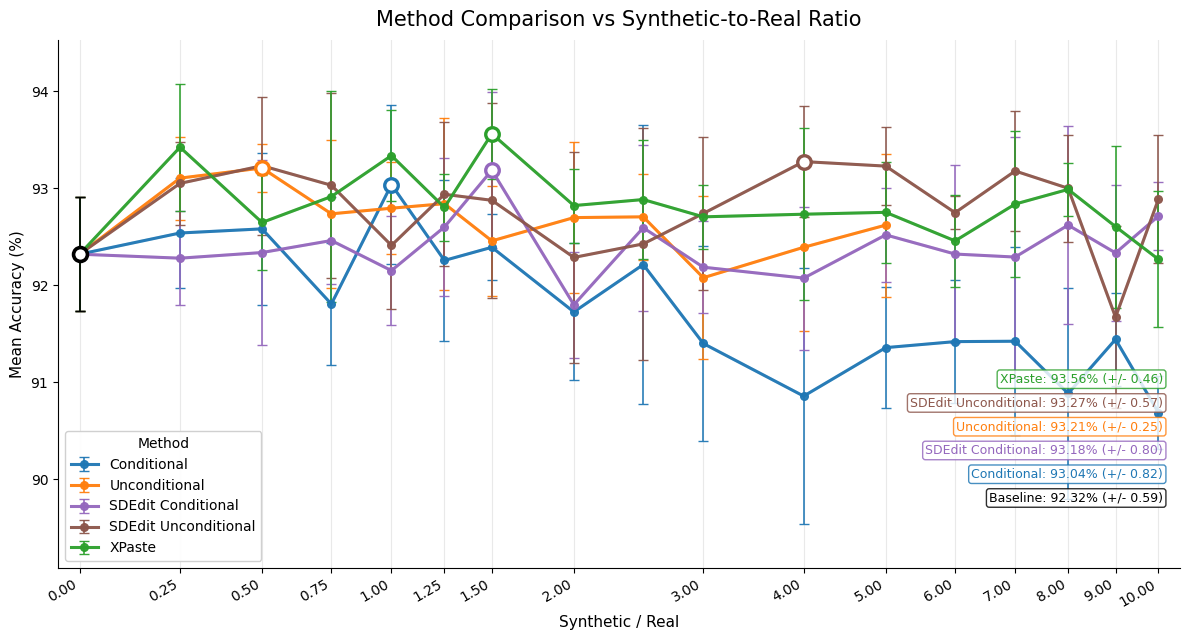

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Toggle this:
# False -> linear x (synthetic/real)
# True  -> log-like x using log10(1 + synthetic/real)
use_logarithmic_ratio_x = True

methods = results_dict.get("methods", []) if isinstance(results_dict, dict) else []

fig, ax = plt.subplots(figsize=(12, 6.5))
plotted_any = False
peak_points = []
baseline_candidates = []

palette = {
    "Conditional": "#026fbd",
    "Unconditional": "#ff7f0e",
    "SDEdit Conditional": "#c40dac",
    "SDEdit Unconditional": "#8c564b",
    "XPaste": "#2ca02c",
}


def synth_to_real_ratio(synth_count, real_count=4000):
    return synth_count / real_count


def x_transform(r):
    if not use_logarithmic_ratio_x:
        return r
    # log1p-style transform keeps x=0 defined while spreading higher ratios
    return np.log10(1.0 + r)


for method in methods:
    name = method.get("name", "Unnamed")
    x_vals = method.get("x", []) or []
    y_vals = method.get("y", []) or []
    y_std = method.get("y_std", []) or []

    if not x_vals or not y_vals or len(x_vals) != len(y_vals):
        print(f"Skipping {name}: missing or mismatched x/y data")
        continue

    xyz = list(zip(x_vals, y_vals, y_std if len(y_std) == len(y_vals) else [None] * len(y_vals)))
    xyz = sorted(xyz, key=lambda p: p[0])

    x_counts = [p[0] for p in xyz]
    y_sorted = [p[1] for p in xyz]
    yerr_sorted = [p[2] for p in xyz]

    x_ratio = [synth_to_real_ratio(xc) for xc in x_counts]
    x_plot = [x_transform(r) for r in x_ratio]
    color = palette.get(name, None)

    # Baseline candidate from x=0
    if 0 in x_counts:
        i0 = x_counts.index(0)
        baseline_candidates.append(
            {
                "name": name,
                "x_ratio": x_ratio[i0],
                "x_plot": x_plot[i0],
                "y": y_sorted[i0],
                "y_std": yerr_sorted[i0],
            }
        )

    # Peak must exclude x=0
    nonzero_idx = [i for i, x in enumerate(x_counts) if x != 0]
    if nonzero_idx:
        best_i = max(nonzero_idx, key=lambda i: y_sorted[i])
        peak_points.append(
            {
                "name": name,
                "x_ratio": x_ratio[best_i],
                "x_plot": x_plot[best_i],
                "y": y_sorted[best_i],
                "y_std": yerr_sorted[best_i],
                "color": color,
            }
        )

    # Light trend guide
    if len(x_plot) >= 3 and len(set(x_plot)) >= 3:
        xd = np.linspace(min(x_plot), max(x_plot), 250)
        yd = np.interp(xd, x_plot, y_sorted)
        ax.plot(xd, yd, linewidth=2.0, alpha=0.20, color=color, zorder=1)

    # Main line + error bars
    if all(e is not None for e in yerr_sorted):
        ax.errorbar(
            x_plot,
            y_sorted,
            yerr=yerr_sorted,
            fmt="o-",
            linewidth=2.2,
            markersize=5.5,
            capsize=3.5,
            elinewidth=1.2,
            alpha=0.95,
            color=color,
            label=name,
            zorder=3,
        )
    else:
        ax.plot(
            x_plot,
            y_sorted,
            "o-",
            linewidth=2.2,
            markersize=5.5,
            alpha=0.95,
            color=color,
            label=name,
            zorder=3,
        )

    plotted_any = True

if plotted_any:
    # Ticks based on synthetic counts, displayed as synth/4000
    tick_counts = sorted({0, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 12000, 16000, 20000, 24000, 28000, 32000, 36000, 40000})
    tick_ratios = [synth_to_real_ratio(c) for c in tick_counts]
    tick_positions = [x_transform(r) for r in tick_ratios]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{r:.2f}" for r in tick_ratios], rotation=30, ha="right")

    ax.set_xlabel("Synthetic / Real", fontsize=11)
    ax.set_ylabel("Mean Accuracy (%)", fontsize=11)
    mode_name = "" if use_logarithmic_ratio_x else ""
    ax.set_title(f"Method Comparison vs Synthetic-to-Real Ratio", fontsize=15, pad=10)

    ax.grid(True, axis="x", alpha=0.28, linewidth=0.8)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ranked_peaks = sorted(peak_points, key=lambda p: p["y"], reverse=True)
    baseline = baseline_candidates[0] if baseline_candidates else None

    # Peak markers (white center, colored border)
    for peak in ranked_peaks:
        ax.scatter(
            peak["x_plot"],
            peak["y"],
            s=95,
            facecolors="white",
            edgecolors=peak["color"],
            linewidths=2.4,
            zorder=7,
        )

    # Baseline marker + black error bar
    if baseline is not None:
        ax.scatter(
            baseline["x_plot"],
            baseline["y"],
            s=100,
            facecolors="white",
            edgecolors="black",
            linewidths=2.6,
            zorder=8,
        )
        if baseline["y_std"] is not None:
            ax.errorbar(
                baseline["x_plot"],
                baseline["y"],
                yerr=baseline["y_std"],
                fmt="none",
                ecolor="black",
                elinewidth=1.2,
                capsize=3.5,
                zorder=7,
            )

    # Ranking boxes including baseline
    ranking_boxes = [
        {"name": p["name"], "y": p["y"], "y_std": p["y_std"], "color": p["color"]}
        for p in ranked_peaks
    ]
    if baseline is not None:
        ranking_boxes.append(
            {"name": "Baseline", "y": baseline["y"], "y_std": baseline["y_std"], "color": "black"}
        )
    ranking_boxes = sorted(ranking_boxes, key=lambda p: p["y"], reverse=True)

    x_box = 0.985
    y_start = 0.12
    y_step = 0.045
    for i, item in enumerate(ranking_boxes):
        y_box = y_start + (len(ranking_boxes) - 1 - i) * y_step
        if item["y_std"] is not None:
            txt = f"{item['name']}: {item['y']:.2f}% (+/- {item['y_std']:.2f})"
        else:
            txt = f"{item['name']}: {item['y']:.2f}%"

        ax.text(
            x_box,
            y_box,
            txt,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color=item["color"],
            bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=item["color"], alpha=0.82),
            zorder=6,
        )

    ax.legend(title="Method", frameon=True, framealpha=0.92)
    ax.margins(x=0.02, y=0.10)

    plt.tight_layout()
    plt.show()
else:
    print("No plottable method data found in results_dict['methods'].")

## Accuracy normalized by memory usage

NameError: name 'x_scale' is not defined

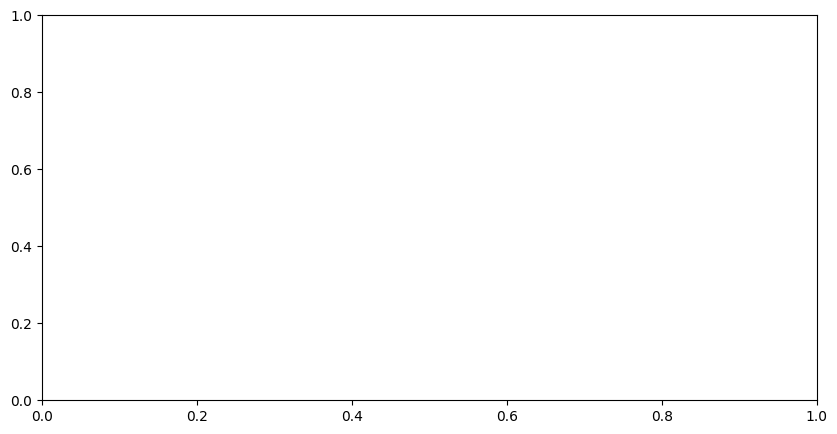

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_sorted, x_scale, 'o-', linewidth=2)

ax.set_xlabel("Resolution (px)")
ax.set_ylabel("Relative Memory Usage")
ax.set_title("Relative Memory Usage vs Resolution")

ax.set_xscale("linear")
ax.set_xticks(x_sorted)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

ax.grid(True, axis="both", alpha=0.3)
ax.set_axisbelow(True)

for xi, yi, scale in zip(x_sorted, y_memory_normalized, x_scale):
    ax.text(xi, scale +4, f"{scale:.2f}", ha="center", fontsize=9)

#ax.set_ylim(min(y_memory_normalized) - max(y_memory_normalized) * 0.05, max(y_memory_normalized) * 1.1)
plt.tight_layout()
plt.show()
